# Notebook 02 — the session funnel (descriptive)

## The session funnel: definition and unit

**Definition (reports/pre_registration.md §1).** The funnel is a sequence of
three reached-step transition rates over sessions: **view → cart**,
**cart → purchase**, **view → purchase**. A session *reaches* a step iff its
`has_*` flag is set (>= 1 event of that type); the step rates are conditional:

| Rate | Definition |
|---|---|
| view→cart | P(cart \| view) — cart sessions among view sessions |
| cart→purchase | P(purchase \| cart) — purchase sessions among cart sessions |
| view→purchase | P(purchase \| view) — purchase sessions among view sessions |

Point estimates carry 95% Wilson CIs (the Stage-02 method in `src/funnel`).

**Unit of analysis.** One row per **`user_session`** (`data/processed/
sessions.parquet` is the `src.funnel.session_features` output, already keyed on
`user_session`). The 272 session ids reused across users (0.006% of sessions,
Stage-01 measured) are the documented, negligible contamination of this key —
the funnel treats each row as one session journey and does not re-derive it
from raw events.

> **The overall funnel figures in this notebook are DESCRIPTIVE, not
> confirmatory** (pre-registration §1). They describe what is observed; they
> support no significance claim. Confirmatory testing begins only with the
> comparisons pinned in pre-registration §3, executed in notebook 04.


In [1]:
import os
import sys
from pathlib import Path


def _find_repo_root() -> Path:
    """Resolve the repo root from the kernel's CWD (cwd-independent cell).

    The build runner launches the kernel from the repo root, but a reader who
    re-executes the .ipynb from another directory must resolve the same data.
    Walk up until a directory contains both src/ and the sessions artifact; the
    is_file() guard below fails loudly instead of silently loading wrong data.
    """
    probe = Path(os.getcwd()).resolve()
    for _ in range(8):
        if (probe / "src").is_dir() and (
            probe / "data" / "processed" / "sessions.parquet"
        ).is_file():
            return probe
        parent = probe.parent
        if parent == probe:
            break
        probe = parent
    raise RuntimeError(
        "repo root not found from CWD="
        + str(Path(os.getcwd()))
        + "; expected a dir with src/ and data/processed/sessions.parquet"
    )


REPO_ROOT = _find_repo_root()
sys.path.insert(0, str(REPO_ROOT))

SESSIONS_FILE = REPO_ROOT / "data" / "processed" / "sessions.parquet"

# Fail loudly if the processed artifact is missing — an empty funnel would
# otherwise sail through and silently change every downstream number.
if not SESSIONS_FILE.is_file():
    raise FileNotFoundError(f"missing processed artifact: {SESSIONS_FILE}")

# Analysis lives in src only — the notebook renders, it does not re-implement
# funnel maths. src.plots import applies the shared matplotlib style, and the
# Agg backend set there is exactly what the headless save of the funnel chart
# needs.
import polars as pl  # noqa: E402
from IPython.display import Image, Markdown, display  # noqa: E402
from src.funnel import funnel_rates  # noqa: E402
import src.plots  # noqa: E402,F401  (applies project style, sets Agg backend)
from src.plots import plot_funnel  # noqa: E402

print(f"repo root:    {REPO_ROOT}")
print(f"sessions:     {SESSIONS_FILE}")


repo root:    /mnt/d/opencode/new20
sessions:     /mnt/d/opencode/new20/data/processed/sessions.parquet


In [2]:
# sessions.parquet IS the session_features output: one row per user_session
# with the has_* reached-step booleans. Materialise once and reuse — the frame
# is the funnel's frozen unit, so every number below comes from the same input.
sessions = pl.read_parquet(SESSIONS_FILE)
n_sessions = sessions.height
print(f"loaded {n_sessions:,} session rows")


loaded 4,535,941 session rows


In [3]:
# Compact session summary on the funnel's own unit. Each count is an absolute
# session count for one reached-step indicator; net_cart is reported both as a
# count and as a share because the two carry different readings (share of ALL
# sessions vs share of cart sessions). count(net_cart>0) and mean(net_cart)
# are the same quantity when net_cart is a boolean — the count is shown to stay
# comparable with the other three indicator counts, the shares to interpret it.
n_view = int(sessions["has_view"].sum())
n_cart = int(sessions["has_cart"].sum())
n_purchase = int(sessions["has_purchase"].sum())
n_net_cart = int(sessions["net_cart"].sum())

_lines = [
    "| step indicator | sessions | share of all sessions |",
    "|---|---:|---:|",
    f"| sessions (all) | {n_sessions:,} | 100.00% |",
    f"| has_view | {n_view:,} | {n_view / n_sessions:.2%} |",
    f"| has_cart | {n_cart:,} | {n_cart / n_sessions:.2%} |",
    f"| has_purchase | {n_purchase:,} | {n_purchase / n_sessions:.2%} |",
    f"| net_cart (cart survived removes) | {n_net_cart:,} "
    f"| {n_net_cart / n_sessions:.2%} (of all) / "
    f"{n_net_cart / n_cart:.2%} (of cart) |",
]
display(Markdown("\n".join(_lines)))


| step indicator | sessions | share of all sessions |
|---|---:|---:|
| sessions (all) | 4,535,941 | 100.00% |
| has_view | 4,280,701 | 94.37% |
| has_cart | 985,780 | 21.73% |
| has_purchase | 155,617 | 3.43% |
| net_cart (cart survived removes) | 802,759 | 17.70% (of all) / 81.43% (of cart) |

**Why these counts differ from the funnel rates below.** The table above is a
set of *absolute* session counts — each indicator is summed over all 4.54M
sessions and reads as its own headline. The funnel rates are *conditional*:
`view→cart = 0.184182` divides the 788,430 sessions that reached **both** view
and cart by all 4,280,701 view sessions, not by all sessions. So the counts
cannot be compared across rows (has_view is 4.28M and has_cart is 0.99M, but
that says nothing about how many viewers carted), while the rates are only
meaningful within their own step's basis. `net_cart` adds a robustness angle:
~82% of cart sessions had a cart survive the session's `remove_from_cart`
events — the `net_cart` column exists to quantify that erosion, it never
replaces `has_cart` in the primary funnel (see `src/funnel.session_features`).


In [4]:
# THE headline funnel: the three pre-registered rates with Wilson CIs, computed
# by src.funnel.funnel_rates and rendered as a markdown table (readers paste it
# into reports/README unchanged). Rendered from the frame — never from
# hand-written literals — so the numbers cannot drift from src.
funnel = funnel_rates(sessions)
_lines = [
    "| step | numerator | denominator | rate | ci_low | ci_high |",
    "|---|---:|---:|---:|---:|---:|",
]
for _row in funnel.iter_rows(named=True):
    _lines.append(
        f"| {_row['step']} | {_row['numerator']:,} | {_row['denominator']:,} "
        f"| {_row['rate']:.6f} | {_row['ci_low']:.6f} | {_row['ci_high']:.6f} |"
    )
display(Markdown("\n".join(_lines)))


| step | numerator | denominator | rate | ci_low | ci_high |
|---|---:|---:|---:|---:|---:|
| view->cart | 788,430 | 4,280,701 | 0.184182 | 0.183816 | 0.184550 |
| cart->purchase | 126,289 | 985,780 | 0.128111 | 0.127452 | 0.128772 |
| view->purchase | 116,412 | 4,280,701 | 0.027195 | 0.027041 | 0.027349 |

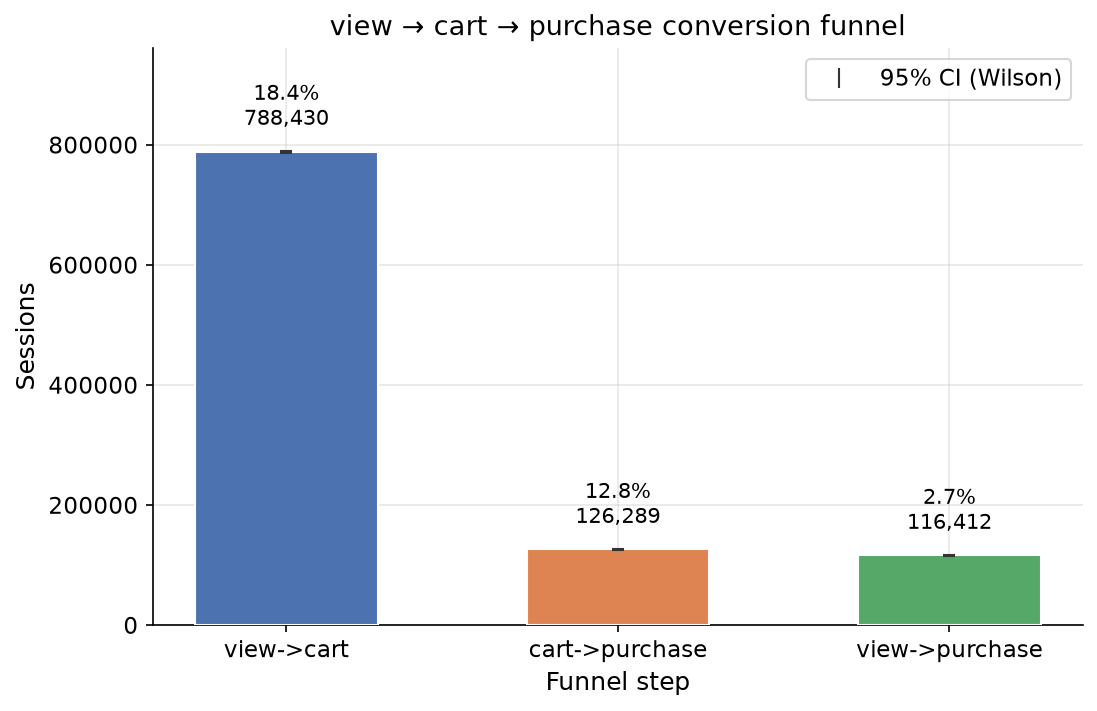

saved /mnt/d/opencode/new20/assets/funnel_chart.png


In [5]:
# Funnel chart on the ABSOLUTE-session-count axis (one bar per step, numerator
# counts, Wilson CI whiskers). The asset path is resolved through the project
# convention and anchored to the repo root, so re-execution from another
# directory writes to the same assets/funnel_chart.png. Displayed inline so the
# executed notebook carries the chart itself, not just a path.
_funnel_plot_path = REPO_ROOT / src.plots.assets_path("funnel_chart")
plot_funnel(funnel, _funnel_plot_path)
display(Image(filename=str(_funnel_plot_path)))
print(f"saved {_funnel_plot_path}")


**Reading the chart — biggest absolute drop.** On the count axis the funnel
loses the most sessions at **view → cart**: from 4,280,701 view sessions to
788,430 that also carted (~3.49M sessions are lost at that step), versus
126,289 of 985,780 at cart → purchase (~0.86M lost). In absolute session
counts, view → cart is therefore the biggest step-wise drop.

Reading honestly: the earlier a step sits in the funnel, the more absolute
flow it naturally carries, so "biggest absolute drop" is a *volume* statement,
not a claim that the drop is more fixable or more important. Whether this loss
is concentrated in a segment — and where a lever actually sits — is the
candidate bottleneck question flagged for notebook 05 (business). No claim is
made here; this notebook is descriptive.


In [6]:
# Step-semantics diagnostics on the funnel's own unit. The two masks mirror the
# boolean contracts in src.funnel._FUNNEL_STEPS exactly: a converting session
# must reach BOTH the basis and the converting step.
#
# direct_purchase: PURCHASED WITHOUT CARTING. These sessions bought without
# ever adding to a cart; has_cart is not an input of view->purchase, so they
# still count toward that step (has_purchase & has_view) and contribute nothing
# to view->cart or cart->purchase.
n_purchase = int(sessions["has_purchase"].sum())
direct_purchase = int((sessions["has_purchase"] & ~sessions["has_cart"]).sum())

# cart_no_view: CARTED WITHOUT VIEWING. These sessions are excluded from
# view->cart (both its numerator and denominator condition on has_view) but
# remain genuine cart-havers for cart->purchase, staying in its denominator.
n_cart = int(sessions["has_cart"].sum())
cart_no_view = int((sessions["has_cart"] & ~sessions["has_view"]).sum())

_lines = [
    "| diagnostic | sessions | share of basis |",
    "|---|---:|---:|",
    f"| purchase without cart (direct purchase) | {direct_purchase:,} "
    f"| {direct_purchase / n_purchase:.2%} of {n_purchase:,} purchase sessions |",
    f"| cart without view | {cart_no_view:,} "
    f"| {cart_no_view / n_cart:.2%} of {n_cart:,} cart sessions |",
]
display(Markdown("\n".join(_lines)))


| diagnostic | sessions | share of basis |
|---|---:|---:|
| purchase without cart (direct purchase) | 29,328 | 18.85% of 155,617 purchase sessions |
| cart without view | 197,350 | 20.02% of 985,780 cart sessions |

**Why the funnel is defined by reached steps, not a strict path.** Every rate
above is built from reached-step booleans (`has_*`), so a session converts a
step whenever both its flags satisfy that step's contract — event *order*
within the session is irrelevant:

- **Purchase without cart (~19% of purchase sessions, 29,328).** These "direct
  purchase" journeys bought without adding to a cart. They still count toward
  **view → purchase** (its numerator is `has_purchase & has_view`, which does
  not require `has_cart`). Excluding them would overstate the drop caused by
  the cart step; including them reflects the real data reality that some buyers
  jump straight to purchase.
- **Cart without view (~20% of cart sessions, 197,350).** Sessions that carted
  without ever viewing are excluded from **view → cart** (both numerator and
  denominator condition on `has_view`) and stay in **cart → purchase**'s
  denominator. If the funnel required a strict *view-then-cart-then-purchase*
  path, both diagnostics would flip these sessions' step membership — a
  robustness variant reserved for notebook 06, explicitly labelled sensitivity.

Neither is data corruption; both are real behaviour the reached-step
definition names explicitly (docstring of `src.funnel.funnel_rates`).


**Whole notebook is descriptive — no significance claims.** Per
`reports/pre_registration.md §1`, the overall funnel figures here describe
what is observed and support no hypothesis. The Wilson CIs quantify sampling
uncertainty of *this* observed dataset's point estimates only; there are no
p-values, no tests, no effect-size or decision claims. Confirmatory testing
(the pre-registered comparisons — families A, B, C with their α, corrections,
sparse rule and practical-significance gate) is the exclusive job of notebook
04, and the candidate-bottleneck question is left open for notebook 05.
